In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

## Phase 0: Kinematic Baseline:

Kinematic Anti-correlation Penalty: Enforces $\frac{\partial S2}{\partial E_{\text{PIN}}} \le 0$ everywhere via automatic differentiation.

Ceiling Anchoring: Anchors the minimum-$E_{\text{PIN}}$ limit to the unquenched high-field ceiling ($S2_{\text{ceiling}} \approx 7.5\text{ mV}\cdot\mu\text{s}$).

In [370]:
set_name = 'FieldScan_Gate0864_Anode1864'
path_s2_areas = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/isotope_areas/Th228/{set_name}_Th228_s2_areas.npz'
# path_s2_areas = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/s2_areas/{set_name}_s2_areas.npz'
path_e_pin = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/alpha_energies/{set_name}_alpha_energies.npz'
path_s2_timing = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/timing/{set_name}_timing.npz'

path_s2_areas_low = '/Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0576_Anode1576_Th228_s2_areas.npz'
path_e_pin_low = '/Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/alpha_energies/FieldScan_Gate0576_Anode1576_alpha_energies.npz'
path_s2_timing_low = '/Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/timing/FieldScan_Gate0576_Anode1576_timing.npz'


raw_s2_area = np.load(path_s2_areas)['s2_areas']
uids = np.load(path_s2_areas)['uids']
energies = np.load(path_e_pin)['energies']
alpha_uids = np.load(path_e_pin)['uids']
raw_e_pin = energies[np.isin(alpha_uids, uids)]  # Align E_PIN with S2 areas based on UIDs

s2_timing = np.load(path_s2_timing) 
s2_width_raw = s2_timing['t_s2_end'] - s2_timing['t_s2_start']
s2_width = s2_width_raw[np.isin(s2_timing['uids'], uids)]  # Align S2 widths with UIDs


raw_s2_area_low = np.load(path_s2_areas_low)['s2_areas']
uids_low = np.load(path_s2_areas_low)['uids']
energies_low = np.load(path_e_pin_low)['energies']
alpha_uids_low = np.load(path_e_pin_low)['uids']
raw_e_pin_low = energies_low[np.isin(alpha_uids_low, uids_low)]  # Align E_PIN with S2 areas based on UIDs

s2_timing_low = np.load(path_s2_timing_low) 
s2_width_raw = s2_timing_low['t_s2_end'] - s2_timing_low['t_s2_start']
s2_width_low = s2_width_raw[np.isin(s2_timing_low['uids'], uids_low)]  # Align S2 widths with UIDs

[Text(0.5, 0, 'S2 Area (mV*us)'),
 Text(0, 0.5, 'S2 Width (us)'),
 Text(0.5, 1.0, 'S2 Width vs S2 Area, E_drift = 2000 V/cm')]

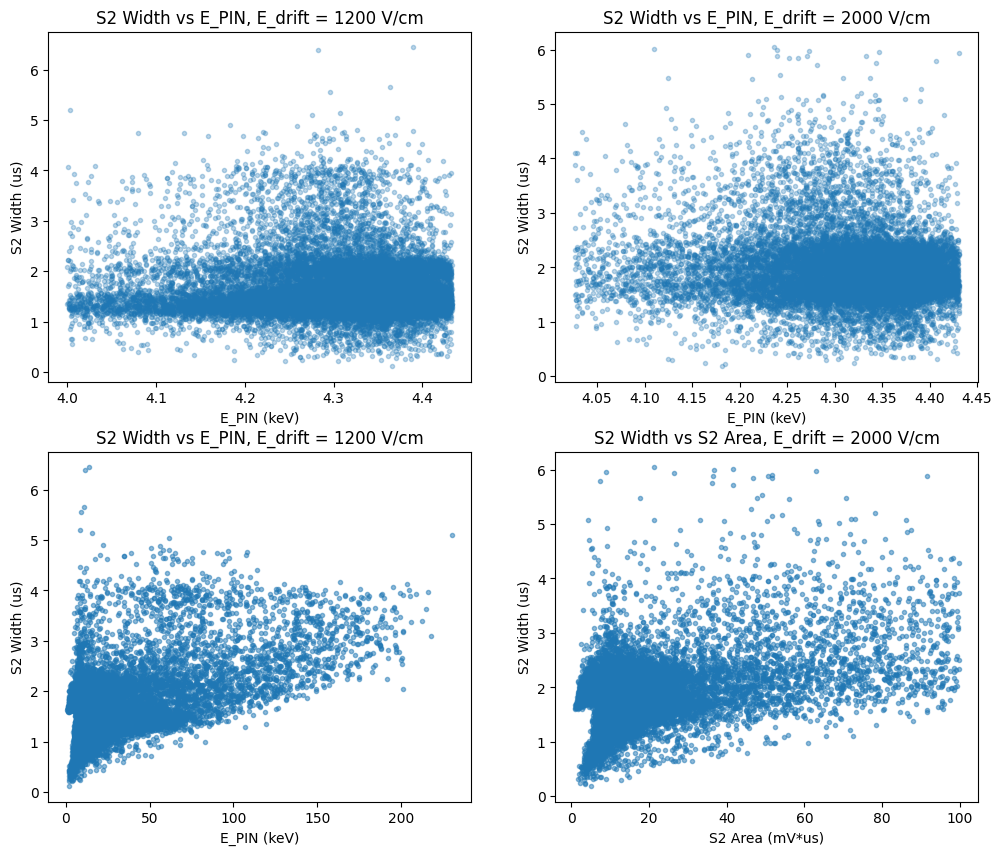

In [240]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0,0].plot(raw_e_pin_low, s2_width_low, '.', alpha=0.3, label='$E_{drift}$ = 1200 V/cm')
ax[0,1].plot(raw_e_pin, s2_width, '.', alpha=0.3, label='$E_{drift}$ = 2600 V/cm')
ax[0,0].set(xlabel='E_PIN (keV)', ylabel='S2 Width (us)', title='S2 Width vs E_PIN, E_drift = 1200 V/cm')
ax[0,1].set(xlabel='E_PIN (keV)', ylabel='S2 Width (us)', title='S2 Width vs E_PIN, E_drift = 2000 V/cm')

ax[1,0].plot(raw_s2_area_low, s2_width_low, '.', alpha=0.5, label='Data Points')
ax[1,0].set(xlabel='E_PIN (keV)', ylabel='S2 Width (us)', title='S2 Width vs E_PIN, E_drift = 1200 V/cm')
ax[1,1].plot(raw_s2_area[raw_s2_area < 100], s2_width[raw_s2_area < 100], '.', alpha=0.5, label='Data Points')
ax[1,1].set(xlabel='S2 Area (mV*us)', ylabel='S2 Width (us)', title='S2 Width vs S2 Area, E_drift = 2000 V/cm')


[Text(0.5, 0, 'S2 Width (us)'),
 Text(0, 0.5, 'Counts'),
 Text(0.5, 1.0, 'S2 Width Distribution, E_drift = 2000 V/cm')]

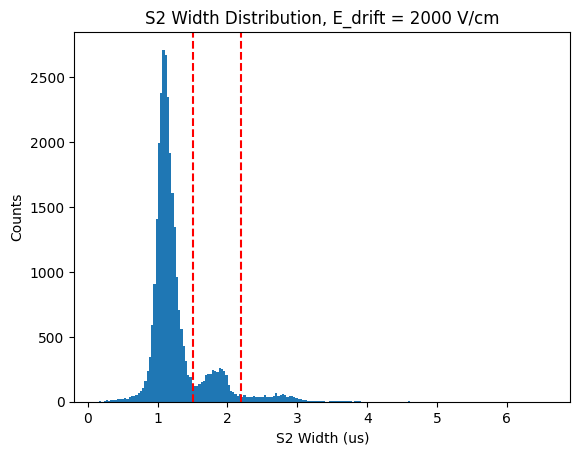

In [316]:
plt.hist(s2_width, bins=200);
plt.axvline(x=1.5, color='red', linestyle='--', label='Width Cut 1.7 us')
plt.axvline(x=2.2, color='red', linestyle='--', label='Width Cut 2.4 us')
plt.gca().set(xlabel='S2 Width (us)', ylabel='Counts', title='S2 Width Distribution, E_drift = 2000 V/cm')

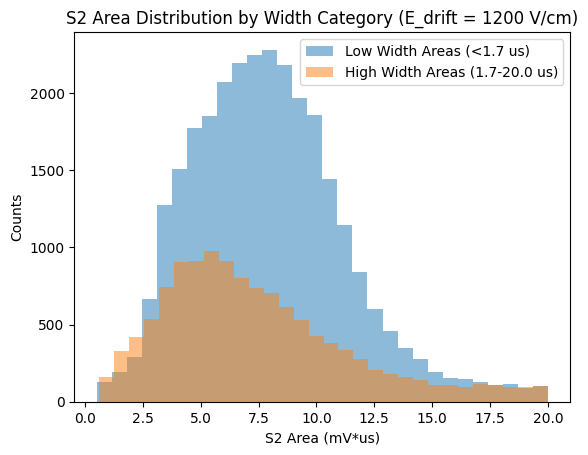

In [166]:
low_width_areas = raw_s2_area_low[(s2_width_low < 1.7)]
low_width_areas = low_width_areas[low_width_areas < 20]
high_width_areas = raw_s2_area_low[(s2_width_low >= 1.7) & (raw_s2_area_low < 20.0)]
high_width_areas = high_width_areas[high_width_areas < 20]
plt.hist(low_width_areas, bins=30, alpha=0.5,  label='Low Width Areas (<1.7 us)')
plt.hist(high_width_areas, bins=30, alpha=0.5, label='High Width Areas (1.7-20.0 us)')
plt.gca().set(xlabel='S2 Area (mV*us)', ylabel='Counts', title='S2 Area Distribution by Width Category (E_drift = 1200 V/cm)')
plt.legend()

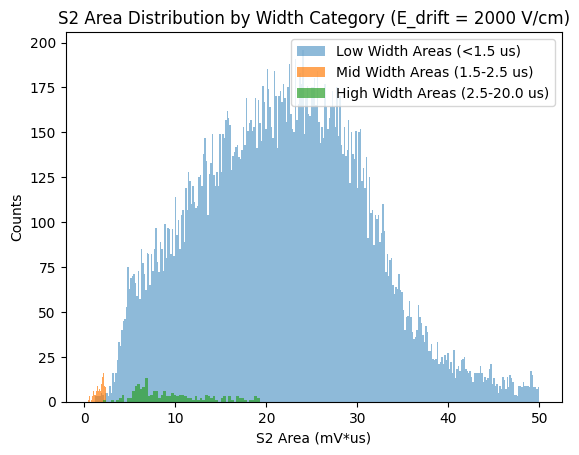

In [180]:
low_width_areas = raw_s2_area[(s2_width < 1.4)]
low_width_areas = low_width_areas[low_width_areas < 50]
mid_width_areas = raw_s2_area[(s2_width >= 1.4) & (raw_s2_area < 2.4)]
high_width_areas = raw_s2_area[(s2_width >= 2.4) & (raw_s2_area < 50.0)]
high_width_areas = high_width_areas[high_width_areas < 20]
plt.hist(low_width_areas, bins=300, alpha=0.5,  label='Low Width Areas (<1.5 us)')
plt.hist(mid_width_areas, bins=30, alpha=0.7,  label='Mid Width Areas (1.5-2.5 us)')
plt.hist(high_width_areas, bins=60, alpha=0.7, label='High Width Areas (2.5-20.0 us)')
plt.gca().set(xlabel='S2 Area (mV*us)', ylabel='Counts', title='S2 Area Distribution by Width Category (E_drift = 2000 V/cm)')
plt.legend()

## Evaluate method on raw waveforms

In [4]:
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.core.config import TimingConfig
from RaTag.plotting import plot_waveform
from RaTag.io import file_ops
from RaTag.waveform.preprocessing import moving_average, subtract_pedestal
from RaTag.thgem_tpc.recoil_workflow import _find_left_boundary, _find_right_boundary, _integrate_s2_areas

In [5]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run43_analysis.yaml'


config = file_ops.load_yaml(config_path)
run43 = bootstrap_from_config(config_path)   

  🔹 Hydrating state from cache: /Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/set_summaries
  → Hydrated 14 PMT Sets and 14 Alpha Sets. (Multi-Isotope: True)


In [401]:
set1.name

'FieldScan_Gate0864_Anode1864'

In [320]:
set1 = run43.sets[7]
# aset1 = run47.alpha_sets[0]
file_idx = 0
frame_idx = 0
v_min = 10.0
wf = file_ops.load_wfm(set1.source_dir / set1.filenames[file_idx])
# wfa = load_alpha(aset1.source_dir / aset1.filenames[file_idx])

wf_smooth = moving_average(wf, window=1000)
wf_sub = subtract_pedestal(wf_smooth, 200)
v_sliced = wf_sub.v
t_sliced = wf_sub.t
peak_idx = np.argmax(v_sliced, axis=1)
peak_heights = v_sliced[np.arange(len(v_sliced)), peak_idx]
peak_times = t_sliced[peak_idx]

In [321]:
config = TimingConfig()

start_times, pass_left = _find_left_boundary(
        v_sliced, t_sliced, peak_idx, peak_heights, peak_times, 
        config.s2_fraction, config.s2_fallback_window_left
    )
    
end_times, pass_right = _find_right_boundary(
        v_sliced, t_sliced, peak_idx, peak_heights, peak_times, 
        config.s2_fraction, config.s2_fallback_window
    )

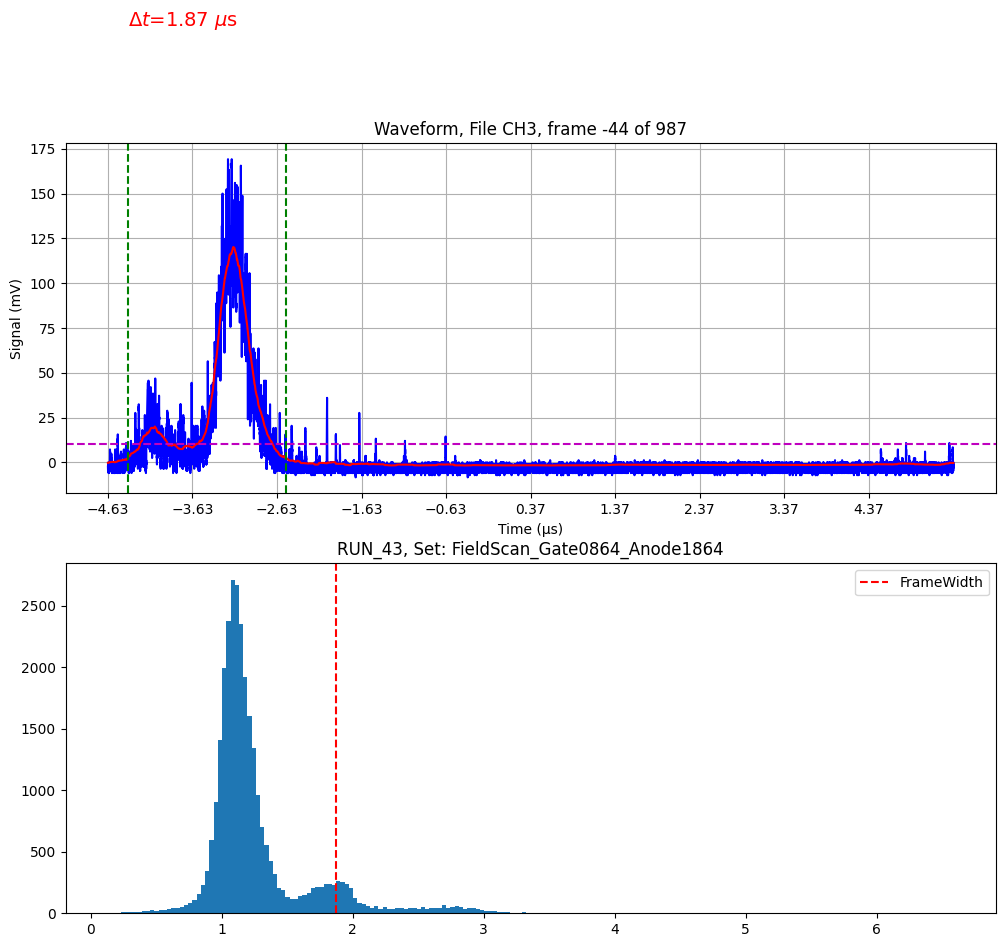

In [373]:
frame_idx += 1
fig, ax = plt.subplots(2, figsize=(12, 10))

plot_waveform(wf, frame=frame_idx, ax=ax[0])
plot_waveform(wf_sub, frame=frame_idx, color='r', ax=ax[0])

width_frame = end_times[frame_idx] - start_times[frame_idx]

# ax.axvline(t_s2_min, color='g', linestyle='--', label='S2 min')
ax[0].axhline(v_min, color='m', linestyle='--', label='Threshold v min')
ax[0].axvline(start_times[frame_idx], color='g', linestyle='--', label='S2 Start')
ax[0].axvline(end_times[frame_idx], color='g', linestyle='--', label='S2 End')
ax[0].text(start_times[frame_idx], peak_heights[frame_idx] * 2.0, f'$\Delta t$={width_frame:.2f} $\mu$s',
          color='r', fontsize=14, verticalalignment='bottom')

ax[1].hist(s2_width, bins=200);
ax[1].axvline(x=width_frame, color='r', linestyle='--', label='FrameWidth')
plt.title(f"{run43.run_id}, Set: {set1.name}")
plt.legend()
# plot_waveform(wfa, frame=frame_idx, ax=ax)

## Check width distribution in Run 50

In [389]:
set_name = 'FieldScan_Gate0188_Anode1288'
# path_s2_areas = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN50_EL27p5kVcm/isotope_areas/Th228/{set_name}_Th228_s2_areas.npz'
path_s2_areas = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN50_EL27p5kVcm/s2_areas/{set_name}_s2_areas.npz'
path_e_pin = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN50_EL27p5kVcm/alpha_energies/{set_name}_alpha_energies.npz'
path_s2_timing = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN50_EL27p5kVcm/timing/{set_name}_timing.npz'

# path_s2_areas_low = '/Users/pabloherrero/sabat/RaTagging/processed/RUN50_EL27p5kVcm/isotope_areas/Th228/FieldScan_Gate0576_Anode1576_Th228_s2_areas.npz'
# path_e_pin_low = '/Users/pabloherrero/sabat/RaTagging/processed/RUN50_EL27p5kVcm/alpha_energies/FieldScan_Gate0576_Anode1576_alpha_energies.npz'
# path_s2_timing_low = '/Users/pabloherrero/sabat/RaTagging/processed/RUN50_EL27p5kVcm/timing/FieldScan_Gate0576_Anode1576_timing.npz'


raw_s2_area = np.load(path_s2_areas)['s2_areas']
uids = np.load(path_s2_areas)['uids']
energies = np.load(path_e_pin)['energies']
alpha_uids = np.load(path_e_pin)['uids']
raw_e_pin = energies[np.isin(alpha_uids, uids)]  # Align E_PIN with S2 areas based on UIDs

s2_timing = np.load(path_s2_timing) 
s2_width_raw = s2_timing['t_s2_end'] - s2_timing['t_s2_start']
s2_width = s2_width_raw[np.isin(s2_timing['uids'], uids)]  # Align S2 widths with UIDs


# raw_s2_area_low = np.load(path_s2_areas_low)['s2_areas']
# uids_low = np.load(path_s2_areas_low)['uids']
# energies_low = np.load(path_e_pin_low)['energies']
# alpha_uids_low = np.load(path_e_pin_low)['uids']
# raw_e_pin_low = energies_low[np.isin(alpha_uids_low, uids_low)]  # Align E_PIN with S2 areas based on UIDs

# s2_timing_low = np.load(path_s2_timing_low) 
# s2_width_raw = s2_timing_low['t_s2_end'] - s2_timing_low['t_s2_start']
# s2_width_low = s2_width_raw[np.isin(s2_timing_low['uids'], uids_low)]  # Align S2 widths with UIDs

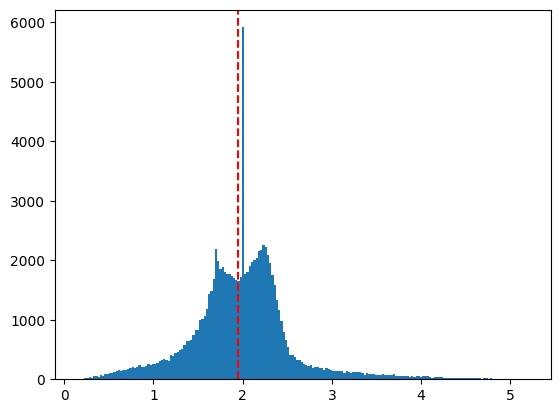

In [390]:
plt.hist(s2_width, bins=200);
plt.axvline(x=1.95, color='red', linestyle='--', label='Width Threshold (1.7 us)')

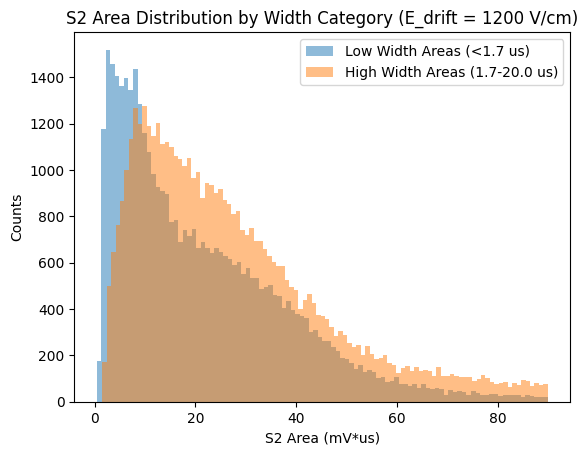

In [391]:
low_width_areas = raw_s2_area[(s2_width < 1.95)]
low_width_areas = low_width_areas[low_width_areas < 90]
high_width_areas = raw_s2_area[(s2_width >= 1.95) & (raw_s2_area < 90.0)]
high_width_areas = high_width_areas[high_width_areas <  90]
plt.hist(low_width_areas, bins=100, alpha=0.5,  label='Low Width Areas (<1.7 us)')
plt.hist(high_width_areas, bins=100, alpha=0.5, label='High Width Areas (1.7-20.0 us)')
plt.gca().set(xlabel='S2 Area (mV*us)', ylabel='Counts', title='S2 Area Distribution by Width Category (E_drift = 1200 V/cm)')
plt.legend()

## Develop Width cut workflow

In [394]:
from RaTag.el_tpc.fit_s2_area import _find_dynamic_lower_bound
from RaTag.io.file_ops import load_npz_arrays, load_s2areas

In [534]:
set0 = run43.sets[4]

In [460]:
# s2_areas = load_s2areas(set0)
s2_areas = load_npz_arrays(set0, 's2_areas')
s2_times = load_npz_arrays(set0, 'timing')
s2_widths = s2_times['t_s2_end'] - s2_times['t_s2_start']
counts, bins = np.histogram(s2_widths, bins=70)
cbins = 0.5 * (bins[1:] + bins[:-1])
mid_valley = _find_dynamic_lower_bound(cbins, counts, max_lower_bound=3)
peak_pos = cbins[np.argmax(counts)]

if mid_valley <= peak_pos:
    raise ValueError("Dynamic lower bound should be greater than the peak position.")

area_uids = s2_areas['uids']
time_uids = s2_times['uids']
filtered_widths = s2_widths[s2_widths < mid_valley]
filtered_uids = time_uids[s2_widths < mid_valley]
filtered_areas = s2_areas['s2_areas'][np.isin(area_uids, filtered_uids)]
one_minus_areas = s2_areas['s2_areas'][~np.isin(area_uids, filtered_uids)]

  Loading s2_areas arrays from: /Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0576_Anode1576_s2_areas.npz
  Loading timing arrays from: /Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/timing/FieldScan_Gate0576_Anode1576_timing.npz


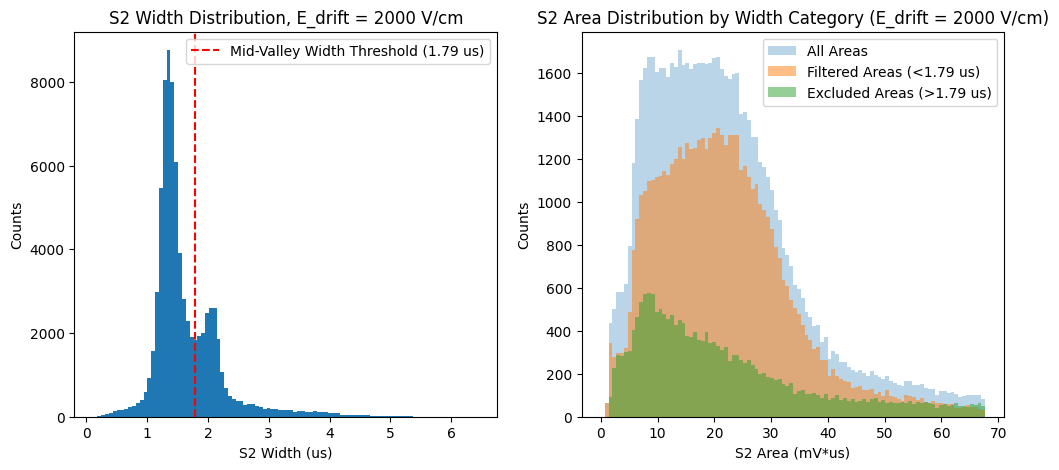

In [465]:

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(s2_widths, bins=100);
ax[0].axvline(x=mid_valley, color='red', linestyle='--', label=f'Mid-Valley Width Threshold ({mid_valley:.2f} us)')
ax[0].set(xlabel='S2 Width (us)', ylabel='Counts', title='S2 Width Distribution, E_drift = 2000 V/cm')
ax[0].legend()

ax[1].hist(s2_areas['s2_areas'], bins=100, alpha=0.3, range=(0, np.mean(filtered_areas) * 3), label='All Areas')
ax[1].hist(filtered_areas, bins=100, alpha=0.5, range=(0, np.mean(filtered_areas) * 3), label=f'Filtered Areas (<{mid_valley:.2f} us)')
ax[1].hist(one_minus_areas, bins=100, alpha=0.5, range=(0, np.mean(filtered_areas) * 3), label=f'Excluded Areas (>{mid_valley:.2f} us)')
ax[1].set(xlabel='S2 Area (mV*us)', ylabel='Counts', title='S2 Area Distribution by Width Category (E_drift = 2000 V/cm)')
ax[1].legend()

# Phase 0

In [7]:
from RaTag.simulations import pinn

In [16]:
set_name = 'FieldScan_Gate0960_Anode1960'
path_s2_areas = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/isotope_areas/Th228/{set_name}_Th228_s2_areas.npz'
# path_s2_areas = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/s2_areas/{set_name}_s2_areas.npz'
path_e_pin = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/alpha_energies/{set_name}_alpha_energies.npz'
path_s2_timing = f'/Users/pabloherrero/sabat/RaTagging/processed/RUN43_EL25kVcm/timing/{set_name}_timing.npz'


raw_s2_area = np.load(path_s2_areas)['s2_areas']
areas_uids = np.load(path_s2_areas)['uids']
energies_raw = np.load(path_e_pin)['energies']
alpha_uids = np.load(path_e_pin)['uids']

s2_timing = np.load(path_s2_timing) 
width_raw = s2_timing['t_s2_end'] - s2_timing['t_s2_start']

t_s1 = -1.5
dt_raw = s2_timing['t_s2_peak'] - t_s1

timing_uids = s2_timing['uids']
first_filter = timing_uids[np.isin(timing_uids, areas_uids)] 
widths_th = width_raw[np.isin(timing_uids, areas_uids)]  # Select Th-228 widths only
widths = widths_th[widths_th < 1.5]                 # Filter low width distribution
filtered_uids = first_filter[widths_th < 1.5]  # Align filtered UIDs with widths

delta_t = dt_raw[np.isin( timing_uids, filtered_uids)]  # Align dt with filtered UIDs
s2_areas = raw_s2_area[np.isin(areas_uids, filtered_uids)]  # Align S2 areas with filtered timing based on UIDs
e_pin = energies_raw[np.isin(alpha_uids, filtered_uids)]  # Align E_PIN with S2 areas based on UIDs

len(filtered_uids), len(s2_areas), len(e_pin), len(widths), len(delta_t)

(27185, 27185, 27185, 27185, 27185)

In [17]:
set8 = run43.sets[8]
v_drift = set8.speed_drift
v_drift, set8.time_drift

(2.138, 2.245)

In [21]:
delta_t = torch.tensor(delta_t, dtype=torch.float32)
e_pin = torch.tensor(e_pin, dtype=torch.float32)
s2_areas = torch.tensor(s2_areas, dtype=torch.float32)
s2_width = torch.tensor(widths, dtype=torch.float32)
features_pristine = torch.stack([e_pin, delta_t], dim=1)

# 2. Configure hyperparams & constants
constants = pinn.PhysicalConstants(v_drift=0.185, D_L=0.012, sigma_0=0.082)
hyperparams = pinn.ModelHyperparameters(learning_rate=1e-3, epochs=400, batch_size=64)

# 3. Train
trained_weights, stats, loss_history = pinn.train_phase0(features_pristine,
                                                        s2_areas, s2_width, 
                                                        hyperparams)

# 4. Evaluate actual metrics
results = pinn.evaluate_phase0(trained_weights, stats, 
                               features_pristine, s2_areas, s2_width, constants)

for k, v in results.items():
    print(f"{k}: {v:.4f}")

/var/folders/tb/zxwsw51n6_g6gs5lnxdv2bcr0000gn/T/ipykernel_84644/3481730813.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  delta_t = torch.tensor(delta_t, dtype=torch.float32)
/var/folders/tb/zxwsw51n6_g6gs5lnxdv2bcr0000gn/T/ipykernel_84644/3481730813.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  e_pin = torch.tensor(e_pin, dtype=torch.float32)
/var/folders/tb/zxwsw51n6_g6gs5lnxdv2bcr0000gn/T/ipykernel_84644/3481730813.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s2_areas = torch.tensor(s2_areas, dtype=torch.float32)


Epoch 1/400 -- Training Phase 0...
Epoch 50/400 -- Training Phase 0...
Epoch 100/400 -- Training Phase 0...
Epoch 150/400 -- Training Phase 0...
Epoch 200/400 -- Training Phase 0...
Epoch 250/400 -- Training Phase 0...
Epoch 300/400 -- Training Phase 0...
Epoch 350/400 -- Training Phase 0...
Epoch 400/400 -- Training Phase 0...
n_events: 27185.0000
e_pin_mean: 4.3183
e_pin_std: 0.0965
delta_t_mean: 3.8222
delta_t_std: 1.2420
s2_obs_mean: 23.0655
s2_obs_std: 11.7064
s2_pred_mean: 20.4892
s2_mse: 135.5821
s2_width_mean: 1.0432
s2_width_std: 0.1544
diff_mse: 66.4452


In [22]:
e_pin_np, dt_np, s2_obs_np, s2_pred_np, s2_w_np, exp_w_np = pinn.extract_evaluation_tensors(
    trained_weights, stats, features_pristine, s2_areas, widths, constants
)

pinn.plot_phase0_diagnostics(
    e_pin_np, dt_np, s2_obs_np, s2_pred_np, s2_w_np, exp_w_np,
    output_path="rit_phase0_diagnostics2.png"
)